# Example 1

We consider the following stochastic Volterra integral equation

$$X_t = 1 + \int\limits_0^t s^2 X_s ds + \int\limits_0^t s X_s dB_s, \qquad t \in [0, 0.5),$$

so $f \equiv 1$, $k_1(s,t) = s^2$, $k_2(s,t) = s$ and $T=0.5$ with the exact solution

$$X_t = \exp \left( \frac{t^3}{6} + \int_0^t s dB_s \right), \qquad t \in [0, 0.5).$$

We recall that 

$$\int\limits_0^t f(s) dB_s \sim \mathcal{N} \left(0, \int_0^t f^2 (s) ds \right)$$

is a normally distributed random variable with a variance of $\int_0^t f^2(s) ds$.

So

$$X_t = \exp \left( \frac{t^3}{6} + Z_t \right),$$

with a normal distributed random variable $Z_t \sim \mathcal{N} \left(0, \int_0^t s^2 ds \right) = \mathcal{N} \left(0, \frac{1}{3} t^3 \right)$. Therefore $X_t$ is a [lognormal](https://en.wikipedia.org/wiki/Log-normal_distribution)-distributed random variable with $\mu = \frac{t^3}{6}$ and $\sigma = \sqrt{\frac{t^3}{3}}$.


First we import the required packages and methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nssvie import SVIE
from stochastic.processes.noise import WhiteNoise

and define the function $f$, the kernels $k_1, k_2$ and the parameters for our model:

In [2]:
def f(t):
    """f(t) = 1"""
    return 1

def kernel_1(s, t):
    """k_1(s,t) = s^2"""
    return s**2

def kernel_2(s, t):
    """k_2(s,t) = s"""
    return s

# Set the right hand side of the interval [0,T)
T = 0.5

# Set the number of intervals m
m = 32

h = T/m

# Set the number of approximations
n = 200

Next, we calculate the numerical solution of the given stochastic Volterra integral equation

In [3]:
# Set a seed
np.random.seed(1337)

example_1 = SVIE(f=f, kernel_1=kernel_1, kernel_2=kernel_2, T=T)

# Empty array for the approximate paths
samples_approx_solution = np.empty((n, m))

# Sample paths
for i in range(n):
    samples_approx_solution[i,:] = example_1.solve_numerical(
        m=m,
        solve_method='bpf'
    )

# Calculate mean
approx_solution = samples_approx_solution.mean(axis=0)

And simulate the exact solution

In [4]:
rng = np.random.default_rng()

# Empty array for the exact paths
samples_exact_solution = np.empty((n, m))
times = np.arange(0, T, h)

# Sample paths
for i in range(n):
    samples_exact_solution[i,:] = [
        rng.lognormal(mean=(t**3)/6, sigma=np.sqrt((t**3)/3)) for t in times
        ]

# Calculate mean
exact_solution = samples_exact_solution.mean(axis=0)

Plot the approximate and exact solution

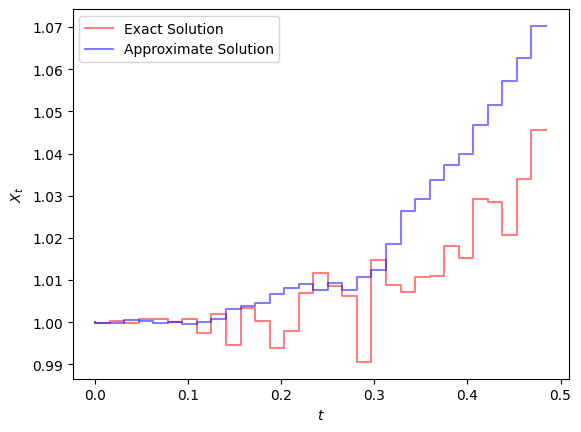

In [5]:
plt.step(
    times,
    exact_solution,
    label='Exact Solution',
    color='red',
    alpha=0.5
)
plt.step(
    times,
    approx_solution,
    label='Approximate Solution',
    color='blue',
    alpha=0.5
)
plt.xlabel(r'$t$')
plt.ylabel(r'$X_t$')

plt.legend()
plt.show()